# 📊 Model Evaluation — Phishing Website Detection

This notebook loads the trained models from `../backend/models/` and performs a thorough evaluation and comparison.

### Models Evaluated
- **Logistic Regression** — Baseline model
- **Random Forest** — Ensemble model
- **XGBoost** — Boosted model

### What This Notebook Covers
- Loading saved models and test data
- Full classification reports
- Confusion matrices
- ROC curves and AUC scores
- Precision-Recall curves
- SHAP explainability for best model
- Feature importance comparison
- Final model recommendation

> **Note:** `web_traffic` and `Links_pointing_to_page` are excluded to match the training pipeline. Evaluation uses 28 features.

---

## 📦 Step 1 — Import Libraries

In [1]:
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import shap

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix,
    classification_report, roc_curve,
    precision_recall_curve, average_precision_score
)

sns.set_theme(style='darkgrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size']  = 11

print('Libraries loaded successfully!')

C:\Users\Hima\AppData\Local\Programs\Python\Python310\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Libraries loaded successfully!


## 📂 Step 2 — Load Dataset and Recreate Test Split

In [2]:
# Load dataset
df = pd.read_csv('../data/phishing.csv')
df['Result'] = df['Result'].replace(-1, 0)

# Drop features not extractable in real-time (must match training)
DROPPED_FEATURES = ['web_traffic', 'Links_pointing_to_page']
df = df.drop(columns=DROPPED_FEATURES)

X = df.drop('Result', axis=1)
y = df['Result']

# Recreate the exact same split used during training
# random_state=42 and stratify=y ensures identical split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

print(f'Test set loaded: {X_test.shape[0]} samples')
print(f'Features used  : {X.shape[1]}')
print(f'Dropped        : {DROPPED_FEATURES}')
print(f'  Phishing (0)   : {(y_test == 0).sum()}')
print(f'  Legitimate (1) : {(y_test == 1).sum()}')


Test set loaded: 3317 samples
Features used  : 28
Dropped        : ['web_traffic', 'Links_pointing_to_page']
  Phishing (0)   : 1470
  Legitimate (1) : 1847


## 🔧 Step 3 — Load Saved Models and Scaler

In [3]:
model_lr  = joblib.load('../backend/models/model_lr.pkl')
model_rf  = joblib.load('../backend/models/model_rf.pkl')
model_xgb = joblib.load('../backend/models/model_xgb.pkl')
scaler    = joblib.load('../backend/models/scaler.pkl')

# Scale test data for Logistic Regression
X_test_scaled = scaler.transform(X_test)

print('Models loaded successfully!')
print('  model_lr.pkl  — Logistic Regression')
print('  model_rf.pkl  — Random Forest')
print('  model_xgb.pkl — XGBoost')
print('  scaler.pkl    — StandardScaler')

Models loaded successfully!
  model_lr.pkl  — Logistic Regression
  model_rf.pkl  — Random Forest
  model_xgb.pkl — XGBoost
  scaler.pkl    — StandardScaler


## 📋 Step 4 — Full Classification Reports

In [4]:
models_eval = {
    'Logistic Regression' : (model_lr,  X_test_scaled),
    'Random Forest'       : (model_rf,  X_test),
    'XGBoost'             : (model_xgb, X_test),
}

target_names = ['Phishing (0)', 'Legitimate (1)']

sep = '=' * 50

for name, (model, X) in models_eval.items():
    y_pred = model.predict(X)
    print(sep)
    print(f'  {name}')
    print(sep)
    print(classification_report(y_test, y_pred, target_names=target_names))
    print()

  Logistic Regression
                precision    recall  f1-score   support

  Phishing (0)       0.92      0.90      0.91      1470
Legitimate (1)       0.92      0.94      0.93      1847

      accuracy                           0.92      3317
     macro avg       0.92      0.92      0.92      3317
  weighted avg       0.92      0.92      0.92      3317


  Random Forest
                precision    recall  f1-score   support

  Phishing (0)       0.96      0.96      0.96      1470
Legitimate (1)       0.96      0.97      0.97      1847

      accuracy                           0.96      3317
     macro avg       0.96      0.96      0.96      3317
  weighted avg       0.96      0.96      0.96      3317


  XGBoost
                precision    recall  f1-score   support

  Phishing (0)       0.97      0.94      0.95      1470
Legitimate (1)       0.95      0.97      0.96      1847

      accuracy                           0.96      3317
     macro avg       0.96      0.95      0.96 

## 📊 Step 5 — Metrics Summary Table

In [5]:
def get_metrics(name, model, X, y):
    y_pred  = model.predict(X)
    y_proba = model.predict_proba(X)[:, 1]
    return {
        'Model'     : name,
        'Accuracy'  : round(accuracy_score(y, y_pred),  4),
        'Precision' : round(precision_score(y, y_pred), 4),
        'Recall'    : round(recall_score(y, y_pred),    4),
        'F1-Score'  : round(f1_score(y, y_pred),        4),
        'ROC-AUC'   : round(roc_auc_score(y, y_proba),  4),
    }

results = [
    get_metrics('Logistic Regression', model_lr,  X_test_scaled, y_test),
    get_metrics('Random Forest',       model_rf,  X_test,        y_test),
    get_metrics('XGBoost',             model_xgb, X_test,        y_test),
]

results_df = pd.DataFrame(results).set_index('Model')

# Highlight best value in each column
print('Metrics Summary (Test Set):')
results_df.style.highlight_max(axis=0, color='#d4f5d4')

Metrics Summary (Test Set):


,Accuracy,Precision,Recall,F1-Score,ROC-AUC
Model,,,,,
Logistic Regression,0.920100,0.919000,0.939400,0.929000,0.976300
Random Forest,0.961400,0.964300,0.966400,0.965400,0.994900
XGBoost,0.956900,0.949800,0.974000,0.961800,0.993000


## 📉 Step 6 — Confusion Matrices

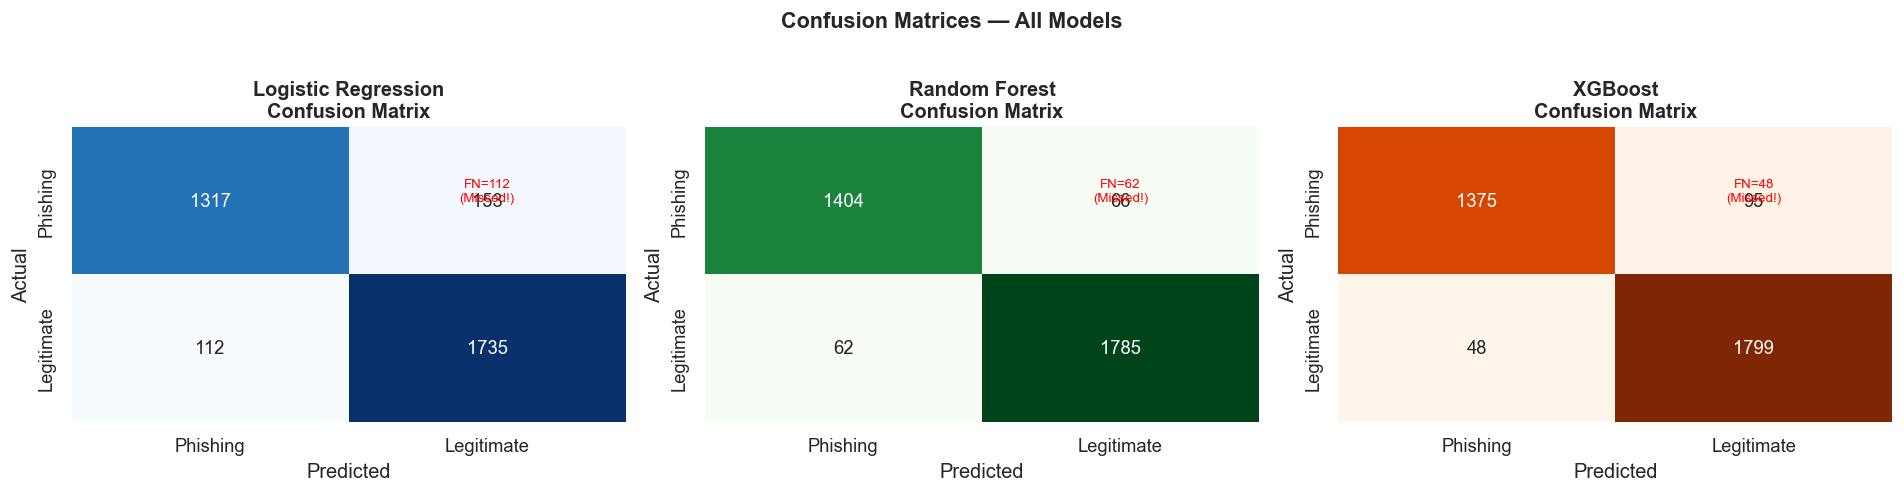

Note: False Negatives (FN) = phishing sites missed — most critical metric!


In [6]:
cmaps  = ['Blues', 'Greens', 'Oranges']
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, (name, (model, X)), cmap in zip(axes, models_eval.items(), cmaps):
    y_pred = model.predict(X)
    cm     = confusion_matrix(y_test, y_pred)

    tn, fp, fn, tp = cm.ravel()

    sns.heatmap(
        cm, annot=True, fmt='d', cmap=cmap,
        ax=ax, cbar=False,
        xticklabels=['Phishing', 'Legitimate'],
        yticklabels=['Phishing', 'Legitimate']
    )
    ax.set_title(f'{name}\nConfusion Matrix', fontweight='bold')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

    # Annotate false negatives (most critical)
    ax.annotate(
        f'FN={fn}\n(Missed!)',
        xy=(1.5, 0.5), fontsize=8,
        color='red', ha='center'
    )

plt.suptitle('Confusion Matrices — All Models', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print('Note: False Negatives (FN) = phishing sites missed — most critical metric!')

## 📈 Step 7 — ROC Curves

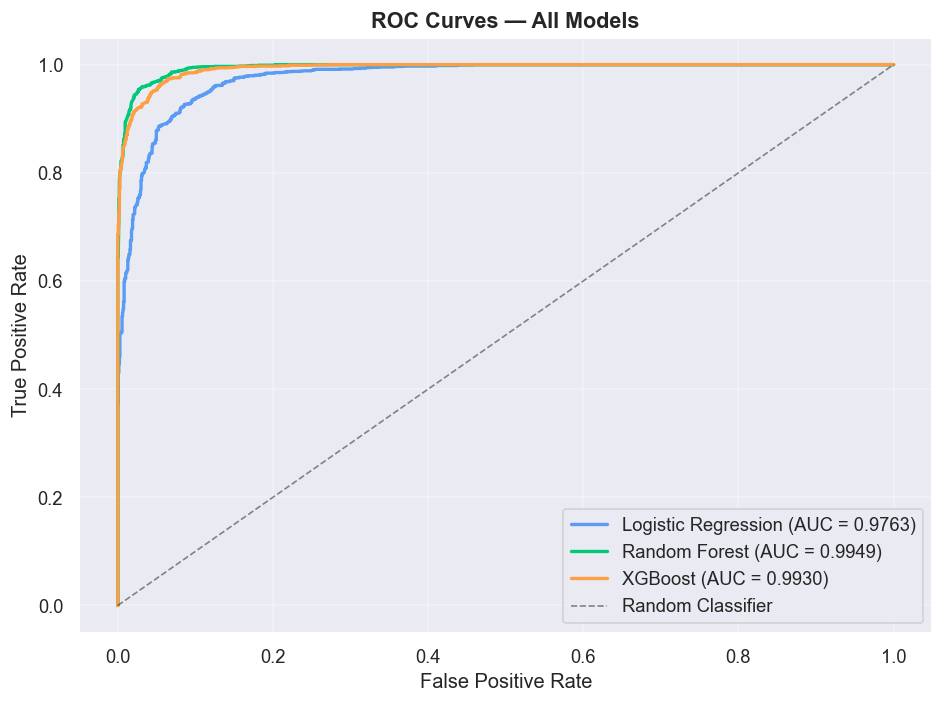

In [7]:
colors = ['#5a9cf5', '#00c97a', '#ff9f43']

plt.figure(figsize=(8, 6))

for (name, (model, X)), color in zip(models_eval.items(), colors):
    y_proba    = model.predict_proba(X)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc         = roc_auc_score(y_test, y_proba)
    plt.plot(fpr, tpr, color=color, linewidth=2, label=f'{name} (AUC = {auc:.4f})')

plt.plot([0, 1], [0, 1], 'k--', linewidth=1, alpha=0.5, label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves — All Models', fontsize=13, fontweight='bold')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 🎯 Step 8 — Precision-Recall Curves

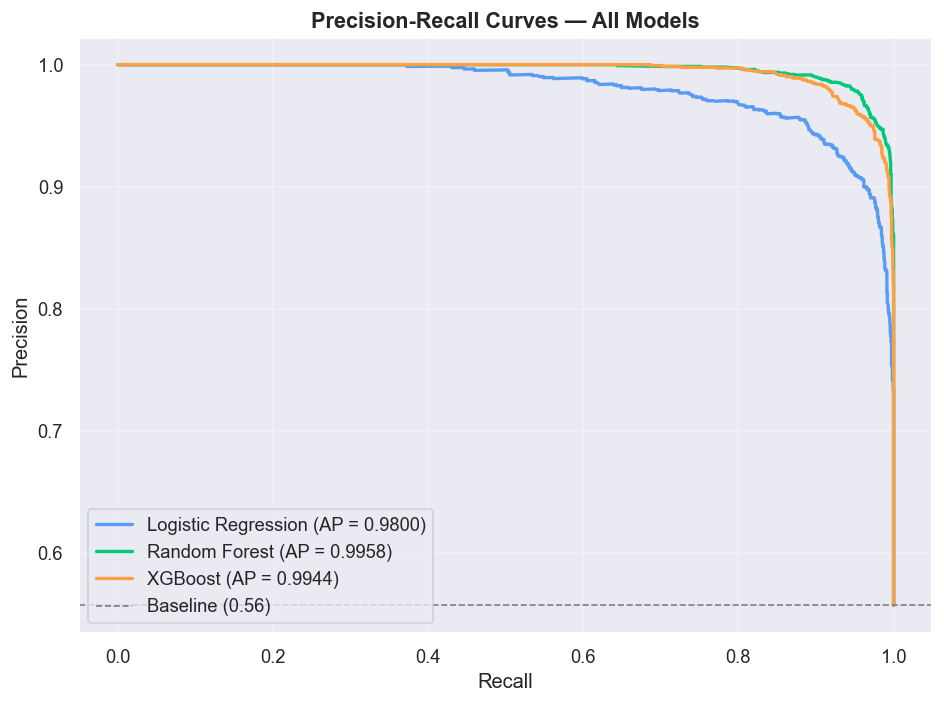

In [8]:
plt.figure(figsize=(8, 6))

for (name, (model, X)), color in zip(models_eval.items(), colors):
    y_proba           = model.predict_proba(X)[:, 1]
    precision, recall, _ = precision_recall_curve(y_test, y_proba)
    ap                = average_precision_score(y_test, y_proba)
    plt.plot(recall, precision, color=color, linewidth=2, label=f'{name} (AP = {ap:.4f})')

# Baseline (random classifier)
baseline = y_test.sum() / len(y_test)
plt.axhline(y=baseline, color='gray', linestyle='--', linewidth=1, label=f'Baseline ({baseline:.2f})')

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curves — All Models', fontsize=13, fontweight='bold')
plt.legend(loc='lower left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 📊 Step 9 — Side-by-Side Metrics Bar Chart

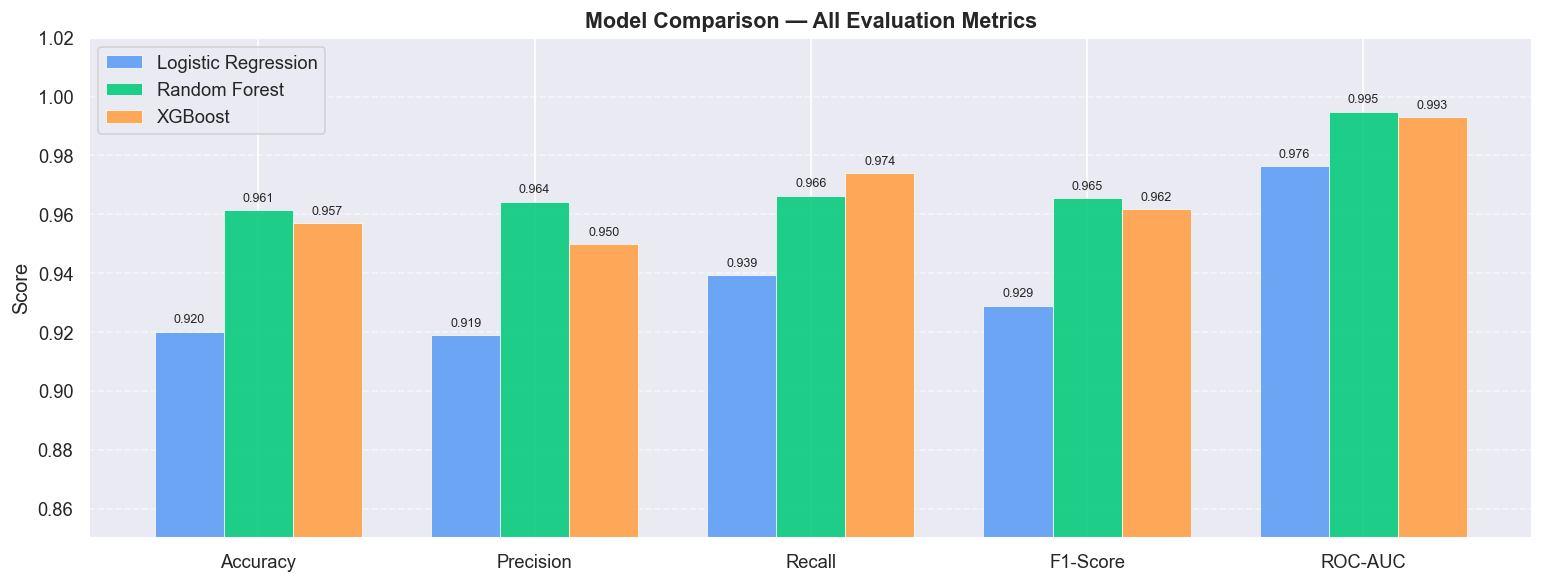

In [9]:
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
x       = np.arange(len(metrics))
width   = 0.25

fig, ax = plt.subplots(figsize=(13, 5))

for i, (model_name, color) in enumerate(zip(results_df.index, colors)):
    vals = results_df.loc[model_name, metrics].values
    bars = ax.bar(
        x + i * width, vals, width,
        label=model_name, color=color,
        alpha=0.88, edgecolor='white', linewidth=0.5
    )
    for bar, val in zip(bars, vals):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.002,
            f'{val:.3f}',
            ha='center', va='bottom', fontsize=7.5
        )

ax.set_xticks(x + width)
ax.set_xticklabels(metrics)
ax.set_ylim(0.85, 1.02)
ax.set_ylabel('Score')
ax.set_title('Model Comparison — All Evaluation Metrics', fontsize=13, fontweight='bold')
ax.legend()
ax.yaxis.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

## 🧠 Step 10 — SHAP Explainability (Best Model)

In [10]:
# Use XGBoost for SHAP (best tree-based model)
print('Computing SHAP values for XGBoost...')
print('(This may take a moment)')

explainer   = shap.TreeExplainer(model_xgb)
shap_values = explainer.shap_values(X_test)

print('SHAP values computed!')

Computing SHAP values for XGBoost...
(This may take a moment)
SHAP values computed!


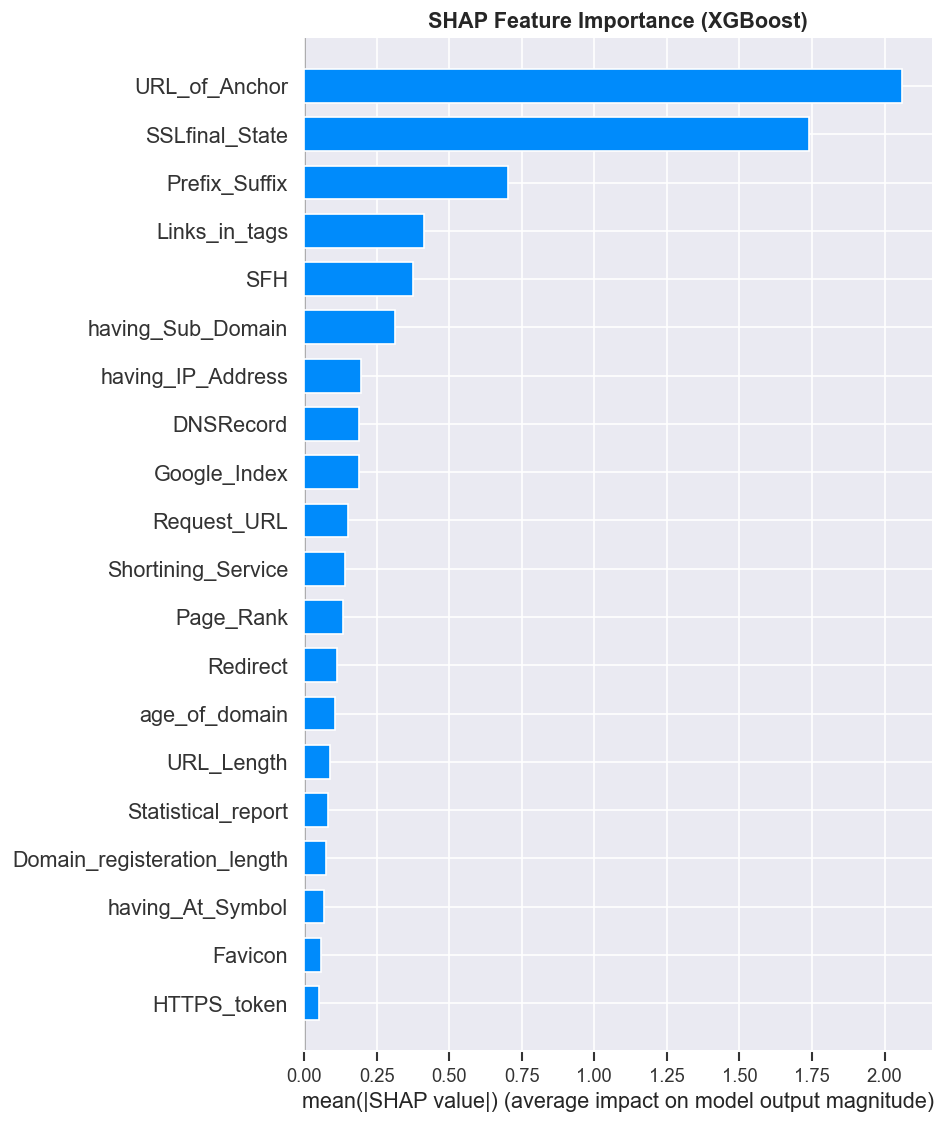

In [11]:
# SHAP Summary Plot — shows feature importance and direction
plt.figure(figsize=(10, 7))
shap.summary_plot(
    shap_values, X_test,
    feature_names=X.columns.tolist(),
    plot_type='bar',
    show=False
)
plt.title('SHAP Feature Importance (XGBoost)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

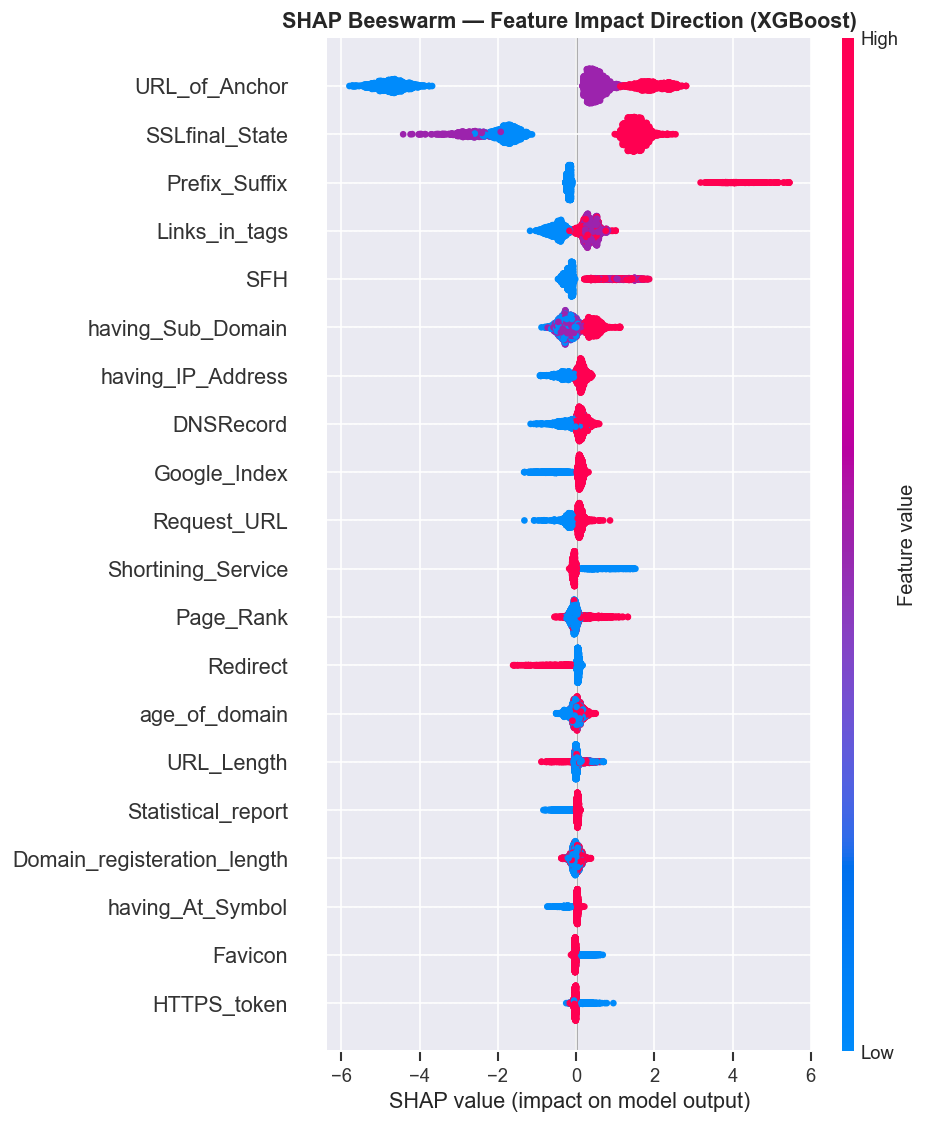

In [12]:
# SHAP Beeswarm Plot — shows feature impact direction
plt.figure(figsize=(10, 7))
shap.summary_plot(
    shap_values, X_test,
    feature_names=X.columns.tolist(),
    show=False
)
plt.title('SHAP Beeswarm — Feature Impact Direction (XGBoost)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

Explaining prediction for sample index: 0
Actual label   : Phishing (0)
Predicted label: 0


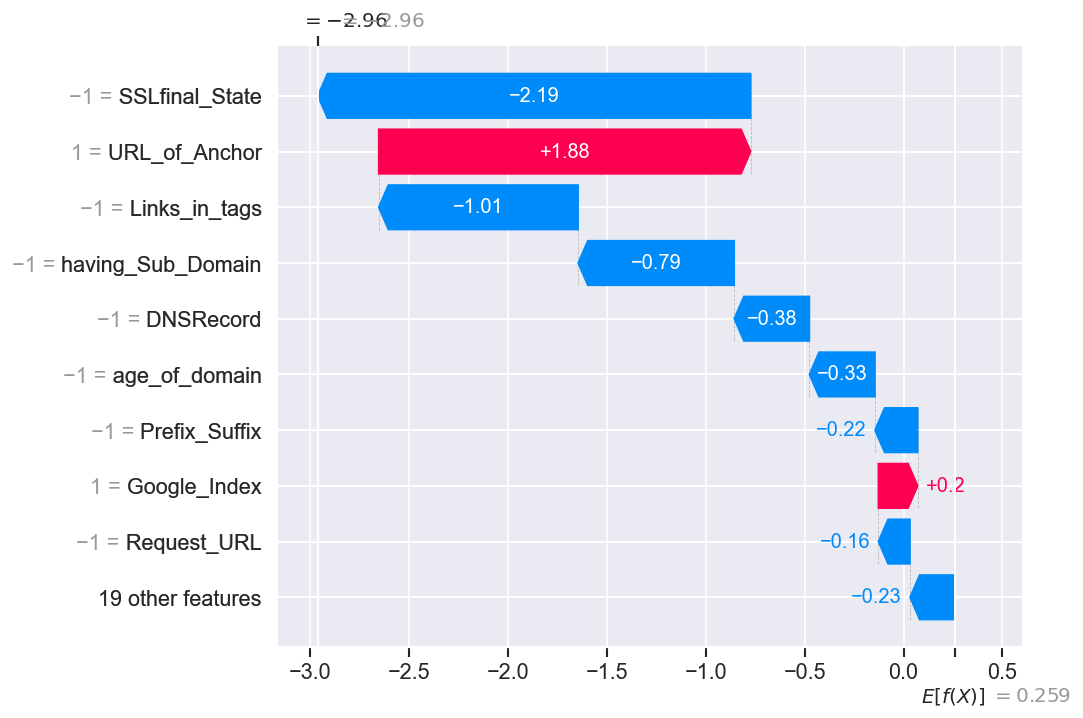

In [13]:
# SHAP Waterfall for a single phishing sample
phishing_idx = (y_test == 0).values.nonzero()[0][0]

print(f'Explaining prediction for sample index: {phishing_idx}')
print(f'Actual label   : Phishing (0)')
print(f'Predicted label: {model_xgb.predict(X_test.iloc[[phishing_idx]])[0]}')

shap.waterfall_plot(
    shap.Explanation(
        values         = shap_values[phishing_idx],
        base_values    = explainer.expected_value,
        data           = X_test.iloc[phishing_idx].values,
        feature_names  = X.columns.tolist()
    )
)

## 🌲 Step 11 — Feature Importance Comparison (RF vs XGBoost)

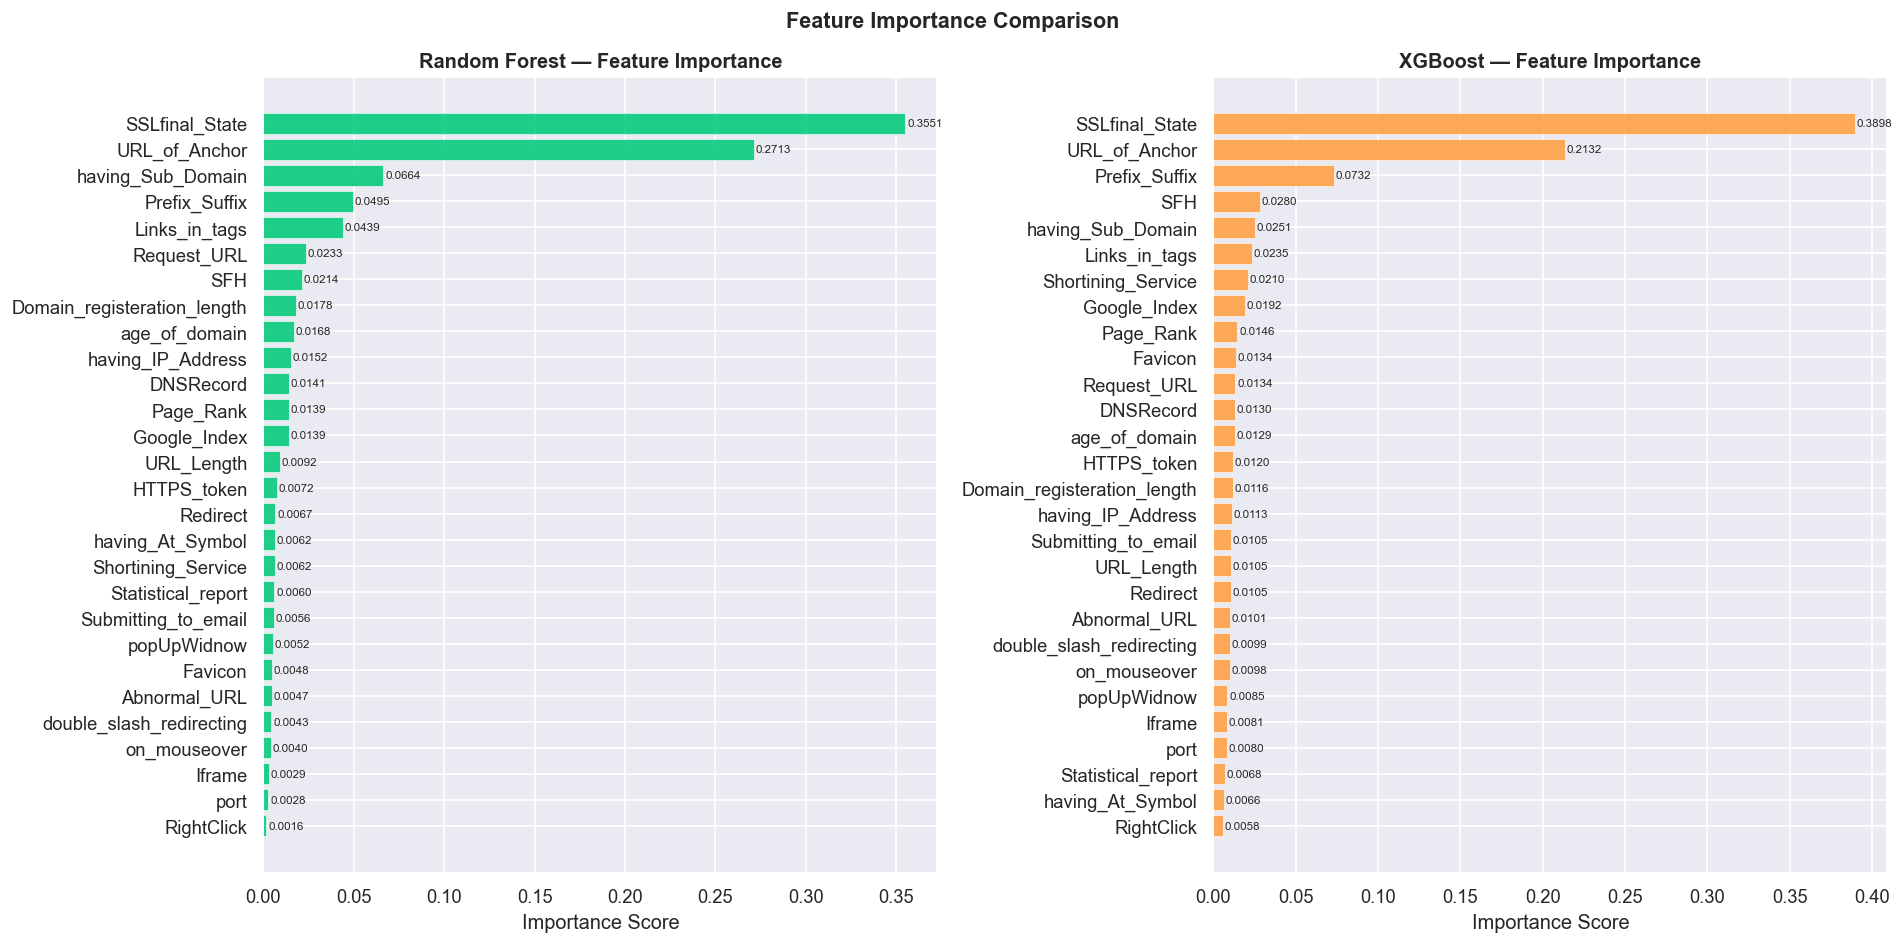

In [14]:
rf_importance  = pd.Series(model_rf.feature_importances_,  index=X.columns, name='Random Forest')
xgb_importance = pd.Series(model_xgb.feature_importances_, index=X.columns, name='XGBoost')

importance_df = pd.DataFrame([rf_importance, xgb_importance]).T
importance_df = importance_df.sort_values('Random Forest', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 8))

for ax, (col, color) in zip(axes, [('Random Forest', '#00c97a'), ('XGBoost', '#ff9f43')]):
    data = importance_df[col].sort_values(ascending=True)
    bars = ax.barh(data.index, data.values, color=color, edgecolor='white', linewidth=0.4, alpha=0.88)
    ax.set_title(f'{col} — Feature Importance', fontsize=12, fontweight='bold')
    ax.set_xlabel('Importance Score')
    for bar, val in zip(bars, data.values):
        ax.text(
            val + 0.001,
            bar.get_y() + bar.get_height() / 2,
            f'{val:.4f}',
            va='center', fontsize=7
        )

plt.suptitle('Feature Importance Comparison', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 🏆 Step 12 — Final Evaluation Summary and Recommendation

In [15]:
best_model_name = results_df['F1-Score'].idxmax()
best_metrics    = results_df.loc[best_model_name]

# False Negative count per model (most critical)
fn_counts = {}
for name, (model, X) in models_eval.items():
    y_pred  = model.predict(X)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
    fn_counts[name] = fn

print('=' * 55)
print('       FINAL EVALUATION SUMMARY')
print('=' * 55)
print()
print('  Metrics on Test Set:')
print(f'  {results_df.to_string()}')
print()
print('  False Negatives (missed phishing sites):')
for name, fn in fn_counts.items():
    print(f'    {name}: {fn} missed')
print()
print(f'  ✅ Recommended Model : {best_model_name}')
print(f'     Accuracy  : {best_metrics["Accuracy"]}')
print(f'     Precision : {best_metrics["Precision"]}')
print(f'     Recall    : {best_metrics["Recall"]}')
print(f'     F1-Score  : {best_metrics["F1-Score"]}')
print(f'     ROC-AUC   : {best_metrics["ROC-AUC"]}')
print()
print('  All models saved in ../backend/models/')
print('  Ready for backend integration!')
print('=' * 55)

       FINAL EVALUATION SUMMARY

  Metrics on Test Set:
                       Accuracy  Precision  Recall  F1-Score  ROC-AUC
Model                                                              
Logistic Regression    0.9201     0.9190  0.9394    0.9290   0.9763
Random Forest          0.9614     0.9643  0.9664    0.9654   0.9949
XGBoost                0.9569     0.9498  0.9740    0.9618   0.9930

  False Negatives (missed phishing sites):
    Logistic Regression: 112 missed
    Random Forest: 62 missed
    XGBoost: 48 missed

  ✅ Recommended Model : Random Forest
     Accuracy  : 0.9614
     Precision : 0.9643
     Recall    : 0.9664
     F1-Score  : 0.9654
     ROC-AUC   : 0.9949

  All models saved in ../backend/models/
  Ready for backend integration!
